In [1]:
import sys
import os
sys.path.insert(1, './Utilities/')

In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

In [3]:
case = '1D'
savedir = './outputs_' + case + '/'
os.makedirs(savedir, exist_ok=True)
save = True

In [4]:
from stefan import Stefan1D
from sampling import *

In [5]:
from AutoDiff import AG_grad, args_requires_grad
from pinns_weights import *
from utils import *
from Trainer import Trainer

In [6]:
from PINNs import Stefan_pinn

### Params

In [7]:
problem = Stefan1D(
    Th=1, 
    Tc=-0.5, 
    Tf=0, 
    L=.2, 
    alpha=0.01, 
    c=0.1, 
    xref=1, 
    tref=1
)

Ste = problem.Ste
Fo = problem.Fo
Th, Tc, T = problem.Th, problem.Tc, problem.T
print('Ste: %.3f, Fo: %.3f, Th: %.3f, Tc: %.3f' % (Ste, Fo, Th, Tc))

Ste: 0.500, Fo: 0.010, Th: 1.000, Tc: -0.500


In [8]:
delta = 0.05

### Ref. solution

In [9]:
file1 = './Utilities/Ref/ref1D_0.5'
file2 = './Utilities/Ref/ref1D_0.005'
validation_data1 = np.loadtxt(file1, delimiter=",")
validation_data2 = np.loadtxt(file2, delimiter=",")

In [10]:
if Ste == 0.5:
    file = file1
    validation_data = validation_data1
elif Ste == 0.005:
    file = file2
    validation_data = validation_data2
of = open(file)
of.readlines()[0]

'# Ste=0.500000, Fo=0.010000, delta=0.050000, nx=251, nt=100\n'

In [11]:
#nx = 201
#nt = 101
nx = 251
nt = 101

In [12]:
t_ref, x_ref, T_ref = np.hsplit(validation_data, 3)

t_ref = t_ref.reshape(-1, nx)
x_ref = x_ref.reshape(-1, nx)
T_ref = T_ref.reshape(-1, nx)

In [13]:
_, _, T_ref2 = np.hsplit(validation_data2, 3)
T_ref2 = T_ref2.reshape(-1, nx)

In [14]:
cmap='coolwarm'
minv = min(T_ref.min(), T_ref2.min())
maxv = max(T_ref.max(), T_ref2.max())
levels = np.linspace(minv, maxv, 10)

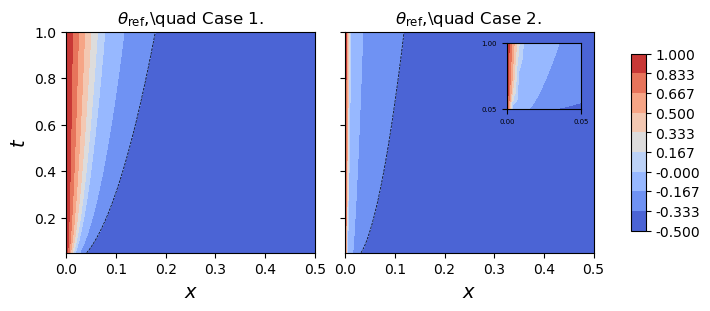

In [15]:
fig, axs = plt.subplots(1, 2, figsize=(7, 3), constrained_layout=True, sharey=True)

ctf = axs[0].contourf(x_ref, t_ref, T_ref, levels, cmap=cmap)
ct = axs[0].contour(x_ref, t_ref, T_ref, levels=[levels[1]], colors='black', linewidths=0.5)

ctf = axs[1].contourf(x_ref, t_ref, T_ref2, levels, cmap=cmap)
ct = axs[1].contour(x_ref, t_ref, T_ref2, levels=[levels[1]], colors='black', linewidths=0.5)

cb = fig.colorbar(ctf, shrink=.8, aspect=12, ax = axs[:], format='%.3f')

axs[0].set_title(r"$\theta_\mathrm{ref}$,\quad Case 1.")
axs[1].set_title(r"$\theta_\mathrm{ref}$,\quad Case 2. ")

axs[0].set_xlim(0., 0.5)
axs[1].set_xlim(0., 0.5)


x1, x2, y1, y2 = 0., 0.05, 0.05, 1
axins = axs[1].inset_axes([0.65, 0.65, 0.3, 0.3], xticks=[x1, x2], yticks=[y1, y2])
axins.contourf(x_ref, t_ref, T_ref2, levels, cmap=cmap)
axins.tick_params(labelsize=5)
axins.set_xlim(x1, x2)
axins.set_ylim(y1, y2)
#axs[i].indicate_inset_zoom(axins, alpha=.5, lw=1, ls="--", edgecolor="k")


axs[0].set_ylabel('$t$', fontsize=14)
axs[0].set_xlabel('$x$', fontsize=14)
axs[1].set_xlabel('$x$', fontsize=14)

if True:
    plt.savefig(savedir+"1D_ref.pdf")
    plt.savefig(savedir+"1D_ref.png")
plt.show()

### Trainer & model

In [16]:
class stefan_problem(Trainer):
    
    def __init__(self, model, 
                 ics_sampler, bcs_sampler, res_sampler,
                 n_ics, n_bcs, n_res,
                 validation_data = None):
        super().__init__(model, validation_data)
        *self.ics_in, self.ics_out = ics_sampler.sample(n_ics, device=self.device)
        *self.bcs_in, self.bcs_out = bcs_sampler.sample(n_bcs, device=self.device)
        *self.res_in, _= res_sampler.sample(n_res, device=self.device)
        #self.res_sampler = res_sampler
            
        self.weights_dict = {'ics': [], 'bcs': [], 'res': []}
        self.losses_dict = {'ics': [], 'bcs': [], 'res': [], 'total':[], 'l2': []}
        
    def loss_fn(self):
        ics = self.net(*self.ics_in)
        ics_mse, ics_error = self.mse_error(ics, self.ics_out)
        
        bcs = self.net(*self.bcs_in)
        bcs_mse, bcs_error = self.mse_error(bcs, self.bcs_out)

        res = self.net_res(*self.res_in)
        res_mse, res_error = self.mse_error(res)

        losses = (ics_mse, bcs_mse, res_mse)
        errors = (ics_error, bcs_error, res_error)
        return losses, errors
        
    
    def train(self, num_epochs, weighting_dict, optim_dict, l2_frequency=1000):
        
        weighting_dict = self._set_weights(weighting_dict)
        self._set_opt(weighting_dict, optim_dict)

        epochs = tqdm(range(num_epochs))
        for epoch in epochs:
            
            """ To Do
            if adaptive:
                if epoch !=0 and epoch % 100 == 0:
                    *self.res_in, _ , res_weights = self.res_sampler._update(self.res_in, save=True)
            """
            
            closure = lambda: self.closure_fn(epoch, weighting_dict)
            loss = self.step(closure)

            # Save losses and weights
            for i, (ll, wl) in enumerate(zip(self.losses_dict.values(), self.weights_dict.values())):
                ll.append(self._last_losses[i])
                wl.append(self.loss_weights[i])
            self.losses_dict["total"].append(loss.item())
            
            epochs.set_description('total loss : %.2e' %(loss.item()))
            if self.validation_data_is_available and (epoch % l2_frequency)==0:
                self.validation_error(epoch)
                

In [17]:
layers = [2] + 6* [20] + [1]
activations = 'tanh'
model = Stefan_pinn(layers, activations, Ste=Ste, Fo=Fo, delta=delta, seed=999)

In [18]:
# Samplers
tl, tu = 5e-2, 1.
xl, xu = 0., 1.

In [19]:
bc1_sampler = Sampler([tl, xl], [tu, xl], T)
bc2_sampler = Sampler([tl, xu], [tu, xu], T)
bcs_sampler = Join_samplers([bc1_sampler, bc2_sampler])

In [20]:
r = 0.2
ics_sampler1 = Sampler(
    l_bounds=[tl, xl],
    u_bounds=[tl, r],
    func=T
)

ics_sampler2 = Sampler(
    l_bounds=[tl, r],
    u_bounds=[tl, xu],
    func=T
)

ics_sampler = Join_samplers([ics_sampler1, ics_sampler2], percentages=[.25, .75])

In [21]:
res_sampler = Sampler([tl, xl], [tu, xu])

In [22]:
n_ics = 1024
n_bcs = 256
n_res = 8000

In [23]:
stefan_trainer = stefan_problem(
    model, 
    ics_sampler, bcs_sampler, res_sampler, 
    n_ics, n_bcs, n_res,
    validation_data=validation_data,
)

### LBFGS

In [120]:
weights = [1., 1., 1e-5]
#weights = stefan_trainer.loss_weights
weights

[1.0, 1.0, 1e-05]

In [121]:
weighting_dict = {
    "method": None,
    "weights": weights
}

In [122]:
optim_dict = dict(
    optimizer="LBFGS",
    max_iter=50,
    line_search_fn="strong_wolfe",
    history_size=100,
    tolerance_grad=1e-7
)

l2_frequency = 1

In [123]:
%%time

n_epochs = 200
stefan_trainer.train(
    n_epochs, 
    optim_dict=optim_dict,
    weighting_dict=weighting_dict,
    l2_frequency=1
)

  0%|          | 0/200 [00:00<?, ?it/s]

CPU times: user 1min 15s, sys: 246 ms, total: 1min 15s
Wall time: 1min 16s


### Adam

In [24]:
weighting_dict = {
    "method": None,
    "weights": [100., 50, 1.],
    }   

In [26]:
optim_dict = {
    'optimizer': 'Adam',
    'lr': 1e-3,
    'exp_lr': True
}
l2_frequency = 100000

In [28]:
%%time

n_epochs = 20000
stefan_trainer.train(
    n_epochs,
    optim_dict=optim_dict,
    weighting_dict=weighting_dict,
    l2_frequency=l2_frequency
)

  0%|          | 0/20000 [00:00<?, ?it/s]

CPU times: user 4min 54s, sys: 3.53 s, total: 4min 57s
Wall time: 4min 59s


### Soft attention

In [23]:
w_ics = torch.rand(n_ics, 1)
w_bcs = torch.rand(n_bcs, 1)
w_res = torch.rand(n_res, 1)
params_data = [w_ics, w_bcs, w_res]

In [24]:
mask_fn = lambda a, b, m, w: a / (1. + torch.exp(- b * (w - m) ))
"""
mask_fns = [
    lambda w: mask_fn(1000, 0.1, 2, w),
    lambda w: mask_fn(50, 0.1, 2, w),
    lambda w: mask_fn(1, 1, 5, w)
]
"""

mask_fns = [
    lambda w: mask_fn(1000, 0.1, 2, w),
    lambda w: mask_fn(1000, 0.1, 2, w),
    lambda w: mask_fn(1, 1, 5, w)
]

In [25]:
weighting_dict = {
    "method": "SA",
    "mask_fns": mask_fns,
    "params_data": params_data,
    #"no_grad": [2],
}   

In [26]:
optim_dict = {
    'optimizer': 'Adam',
    'lr': 1e-3,
    'exp_lr': True
}
l2_frequency = 100000

### Losses:

In [29]:
#n_epochs = len(stefan_trainer.loss)
losses = stefan_trainer.losses_dict
n_epochs = len(losses['ics'])
l2_ep = range(n_epochs)[::l2_frequency]

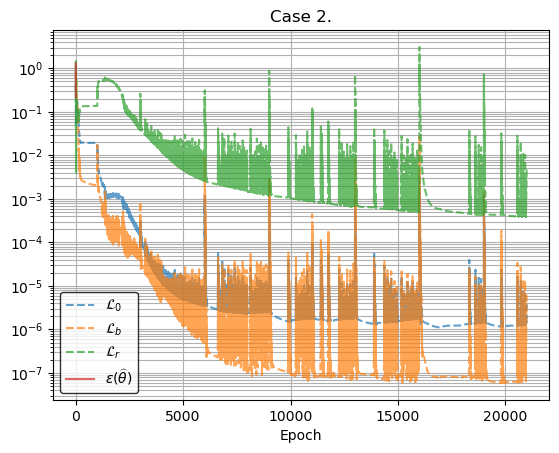

In [31]:
fig, ax = plt.subplots(1, 1)

#"""
ax.plot(losses['ics'], '--', label='$\mathcal{L}_{0}$', alpha=.7)
ax.plot(losses['bcs'], '--', label='$\mathcal{L}_{b}$', alpha=.7)
ax.plot(losses['res'], '--', label='$\mathcal{L}_{r}$', alpha=.7)
#"""
ax.plot(losses['l2'], '-', label=r'$\epsilon(\widehat \theta)$', alpha=.7)

ax.grid(True, "both")
ax.set_yscale('log')
ax.set_xlabel('Epoch', fontsize=10)

ax.set_title(r"Case 2.")
#ax.ticklabel_format(style='sci', axis='x', scilimits=(3, 3))

#ax.legend(fancybox=True, framealpha=1, shadow=True, borderpad=1)
ax.legend(
    loc= 'best', #'lower right',
    frameon=True,
    edgecolor="black",
    facecolor='white'
)

if save:
    plt.savefig(savedir + 'losses.pdf', bbox_inches ='tight')
    plt.savefig(savedir + 'losses.png', bbox_inches ='tight')
plt.show()

In [32]:
try:
    print(f"ics error: {losses['ics'][-1]: .3e}")
    print(f"bcs error: {losses['bcs'][-1]: .3e}")
    print(f"res error: {losses['res'][-1]: .3e}")
    print(f"l2 error: {losses['l2'][-1]: .3e}")
    print(f"min l2 error: {min(losses['l2']): .3e}")
except: pass

ics error:  3.788e-06
bcs error:  6.101e-06
res error:  4.450e-03
l2 error:  2.231e-01
min l2 error:  2.231e-01


In [112]:
np.std([2.6e-2,  2.195e-01], axis=0)*100

9.675

In [93]:
np.argmin(losses['l2'])

1

### Weights:

In [33]:
weights = stefan_trainer.weights_dict
every = 1
weights_ep = range(n_epochs)[::every]

1.0 1.0 1.0


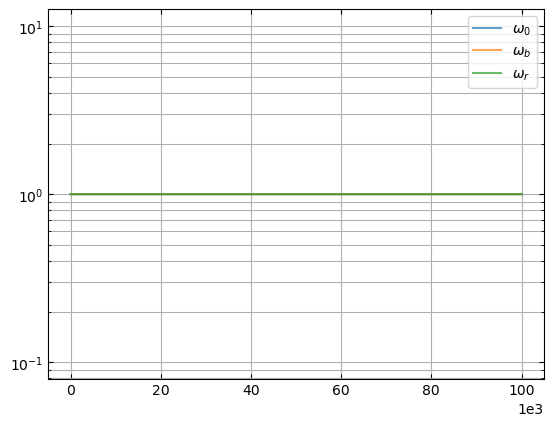

In [34]:
print(np.median(weights['ics']), np.median(weights['bcs']), np.median(weights['res']))

plt.grid(True, which='both')
plt.yscale('log')

plt.plot(weights['ics'][::every], '-', label='$\omega_0$', alpha=.7)
plt.plot(weights['bcs'][::every], '-', label='$\omega_b$', alpha=.7)
plt.plot(weights['res'][::every], '-', label='$\omega_r$', alpha=.7)
plt.ticklabel_format(style='sci', axis='x', scilimits=(3, 3))
#plt.xlim(38000, 40000)

plt.legend()

if save:
    plt.savefig(savefile +'weights.pdf', bbox_inches ='tight')
    plt.savefig(savefile +'weights.png', bbox_inches ='tight')
plt.show()

### Solution

In [34]:
from utils import evaluate

In [36]:
T_pred =  evaluate(
    model,
    t_ref.reshape(-1, 1), 
    x_ref.reshape(-1, 1)
).reshape(-1, nx)

In [37]:
times = t_ref[:, 0]

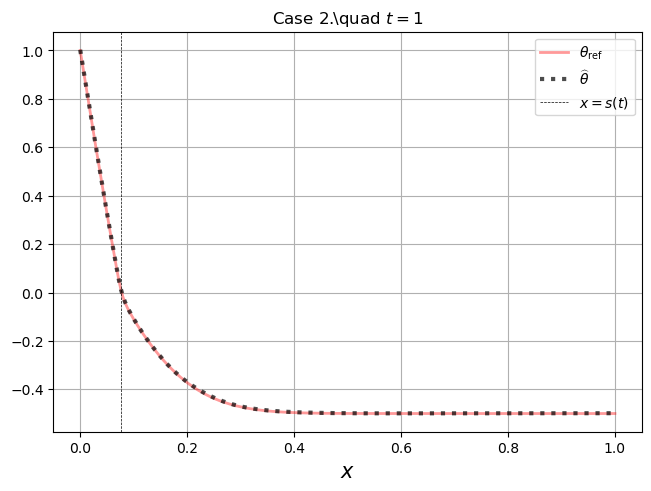

In [40]:
fig, axs = plt.subplots(1, 1, constrained_layout=True)

j = -1
axs.grid(True)
axs.plot(x_ref[0], T_ref[j], 'r-', lw = 2, alpha =.4,  label = r'$\theta_\mathrm{ref}$')
axs.plot(x_ref[0], T_pred[j], ':k',lw = 3, alpha= .7, label = r'$\widehat\theta$')

pos = problem.S(1.)
axs.axvline(pos, c='k', ls='--', lw=0.5, label='$x = s(t)$')
axs.set_title('Case 2.\quad $t = 1$')
axs.set_xlabel('$x$', fontsize = 15)
#axs.set_xlim(-0.01, 0.1)
axs.legend()

#axs[1].set_ylim(-0.6, -0.25)
#axs[1].set_xlim(-.1, 0.1)

#axs[1].legend(bbox_to_anchor=(.9, -0.4), ncol=1, columnspacing = 6)
#axs[1].set_xlim(-0.001, 0.03)
if save:
    plt.savefig(savedir + 'result_bis.pdf', bbox_inches = 'tight')   
    plt.savefig(savedir + 'result_bis.png', bbox_inches = 'tight')   
plt.show()

In [38]:
abs_error = np.abs(T_ref - T_pred)

In [39]:
cmap='coolwarm'
levels = np.linspace(abs_error.min(), 8.5e-01, 10)

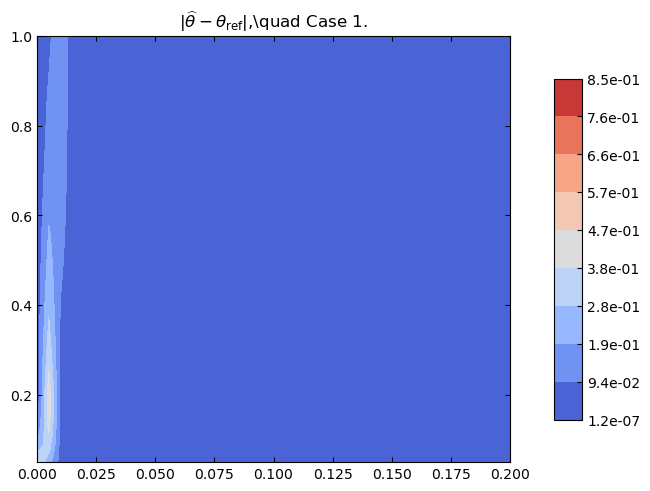

In [40]:
fig, axs = plt.subplots(1, 1, constrained_layout=True)

ctf = axs.contourf(x_ref, t_ref, abs_error, levels=levels, cmap=cmap)
cb = fig.colorbar(ctf, shrink=.8, aspect=12, ax = axs, format='%.1e')

axs.set_title(r"$|\widehat{\theta} - \theta_\mathrm{ref}|$,\quad Case 1.")
#axs.scatter(x_, t_, s=.5, c='k')

axs.set_xlim(0., 0.2)

"""

axs.set_ylim(0.04, 0.1)
"""

"""
axs[0].set_ylabel('$t$', fontsize = 11)
axs[0].set_xlabel('$x$', fontsize = 11)
axs[1].set_xlabel('$x$', fontsize = 11)
"""
if save:
    plt.savefig(savefile+"abs_error.pdf")
    plt.savefig(savefile+"abs_error.png")
plt.show()

### Postpro

In [21]:
layers = [2] + 6* [20] + [1]
activations = 'tanh'

model_1 = Stefan_pinn(layers, activations, Ste=0.5, Fo=Fo, delta=delta, seed=123)
model_2 = Stefan_pinn(layers, activations, Ste=0.005, Fo=Fo, delta=delta, seed=123)

In [22]:
load = torch.load("outputs_1D/case1/model.pth")
model_1.load_state_dict(load['state_dict'], 'cuda')

load = torch.load("outputs_1D/case2/model.pth")
model_2.load_state_dict(load['state_dict'], 'cuda')

<All keys matched successfully>

In [24]:
from utils import evaluate

In [25]:
T_pred_1 =  evaluate(
    model_1,
    t_ref.reshape(-1, 1), 
    x_ref.reshape(-1, 1)
).reshape(-1, nx)

T_pred_2 = evaluate(
    model_2,
    t_ref.reshape(-1, 1), 
    x_ref.reshape(-1, 1)
).reshape(-1, nx)

In [26]:
err_abs_1 = np.abs(T_pred_1 - T_ref)
err_abs_2 = np.abs(T_pred_2 - T_ref2)

vmax = max(err_abs_1.max(), err_abs_2.max())
vmin = min(err_abs_1.min(), err_abs_2.min())

levels = np.linspace(0, vmax, 10)
cmap='coolwarm'

In [27]:
err_abs = [err_abs_1, err_abs_2]

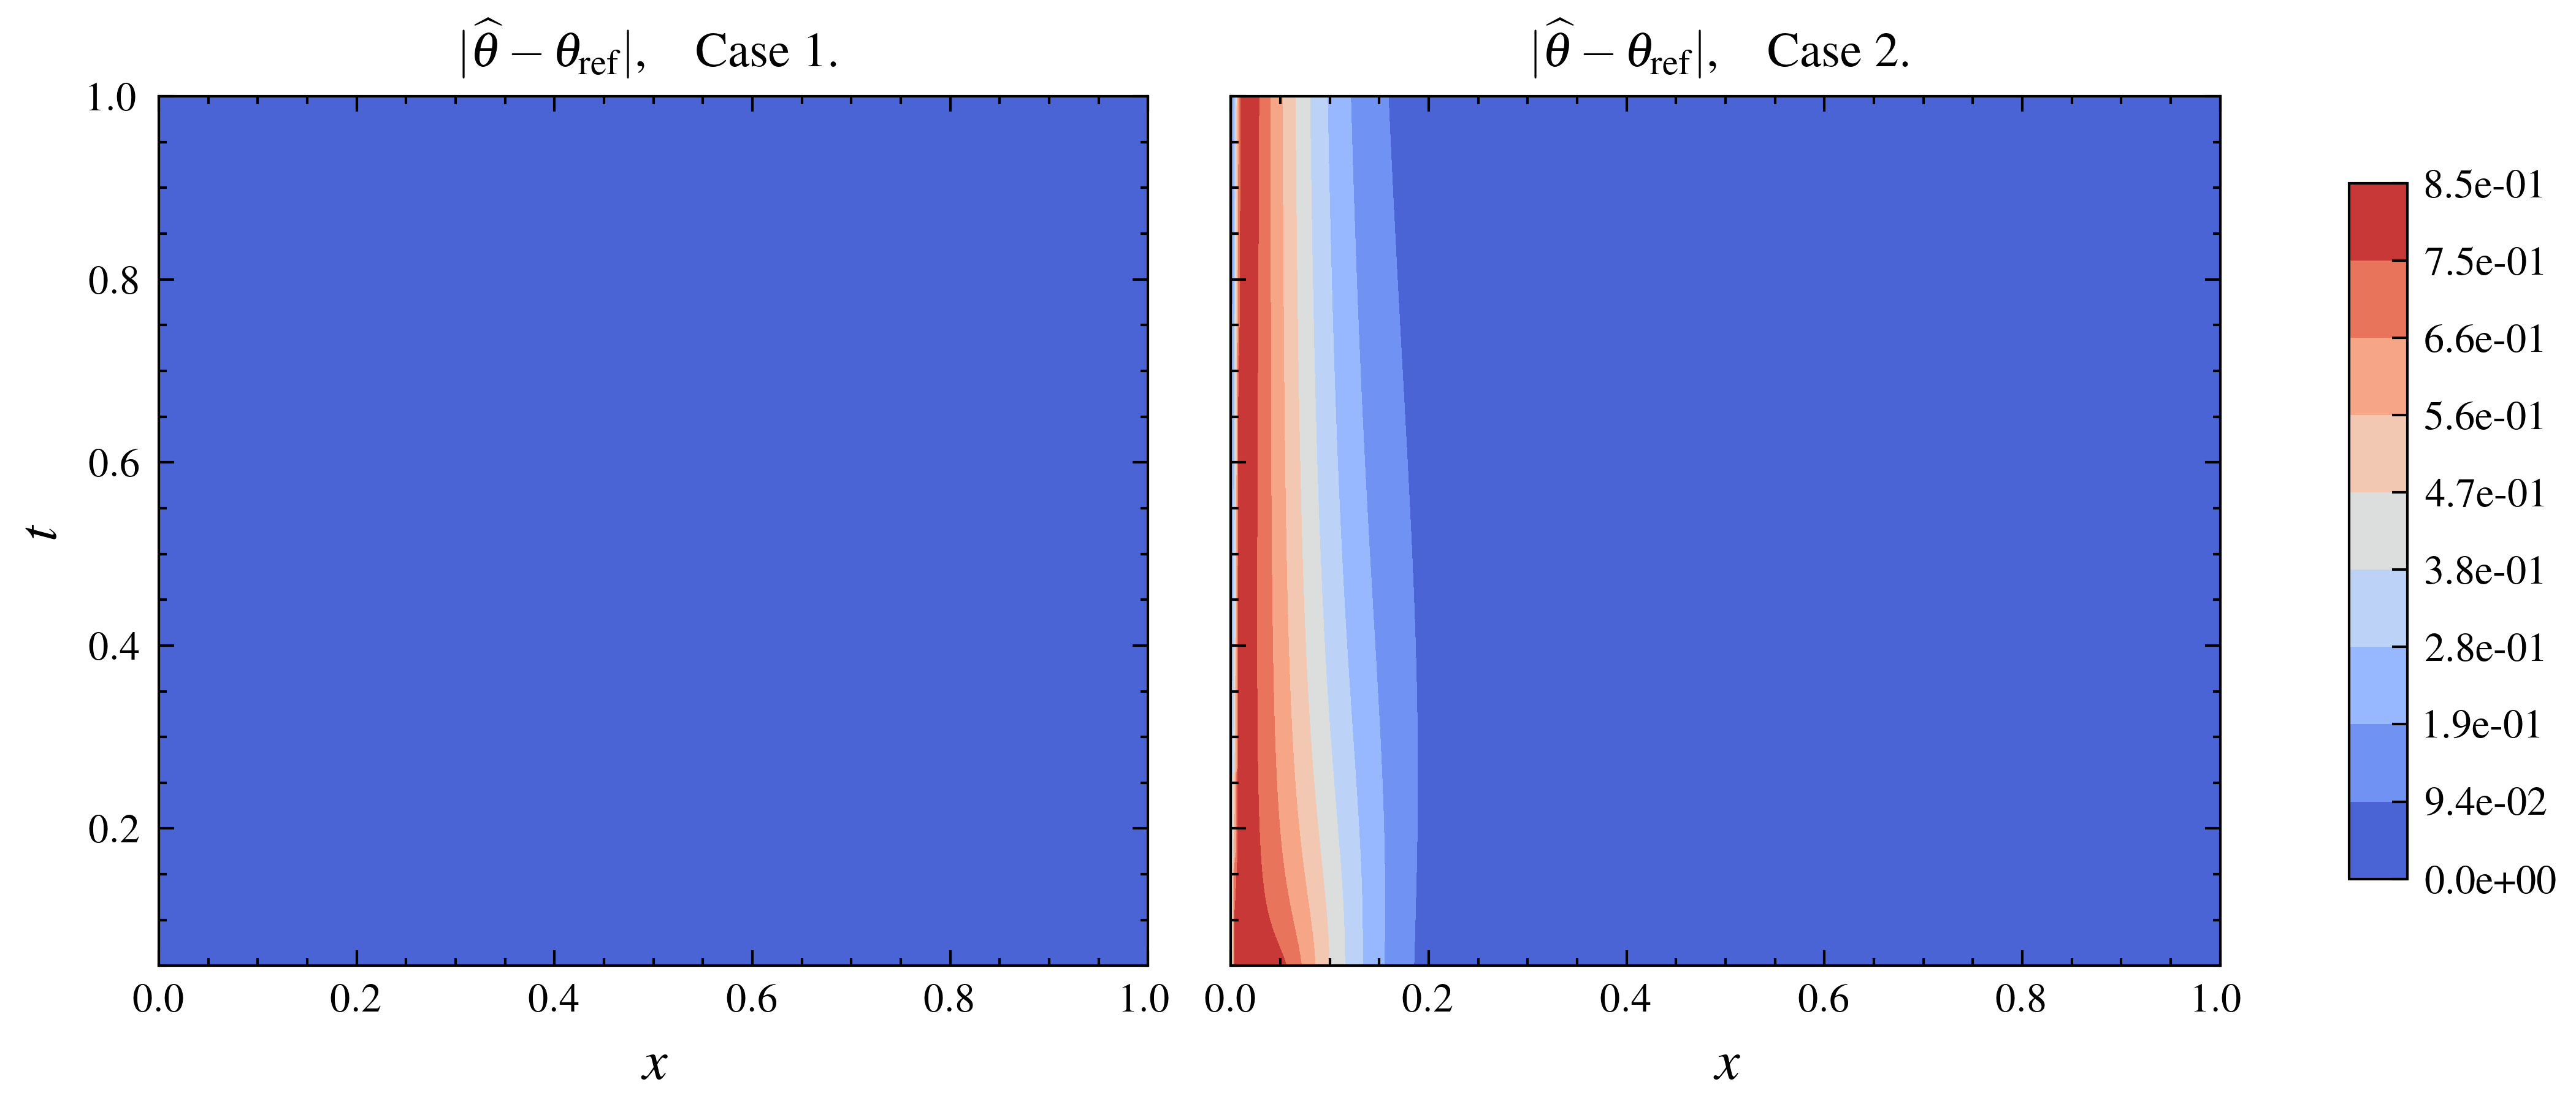

In [28]:
fig, axs = plt.subplots(1, 2, figsize=(7, 3), constrained_layout=True, sharey=True)

ctf = axs[0].contourf(x_ref, t_ref, err_abs_1, levels, cmap=cmap)
ctf = axs[1].contourf(x_ref, t_ref, err_abs_2, levels, cmap=cmap)
cb = fig.colorbar(ctf, shrink=.8, aspect=12, ax = axs[:], format='%.1e')

axs[0].set_title(r"$|\widehat\theta - \theta_\mathrm{ref}|$,\quad Case 1.")
axs[1].set_title(r"$|\widehat\theta - \theta_\mathrm{ref}|$,\quad Case 2. ")

"""
axs[0].set_xlim(0., 0.1)
axs[1].set_xlim(0., 0.1)
"""
axs[0].set_ylabel('$t$', fontsize = 11)
axs[0].set_xlabel('$x$', fontsize = 11)
axs[1].set_xlabel('$x$', fontsize = 11)

"""
x1, x2, y1, y2 = 0., 0.05, 0.05, 1
for i in [0, -1]:
    axins = axs[i].inset_axes([0.65, 0.65, 0.3, 0.3], xticks=[x1, x2], yticks=[y1, y2])
    axins.contourf(x_ref, t_ref, err_abs[i], levels, cmap=cmap)
    axins.tick_params(labelsize=5)
    axins.set_xlim(x1, x2)
    axins.set_ylim(y1, y2)
    #axs[i].indicate_inset_zoom(axins, alpha=.5, lw=1, ls="--", edgecolor="k")
"""

if True:
    plt.savefig(savefile+"1D_err_abs.pdf")
    plt.savefig(savefile+"1D_err_abs.png")
plt.show()

In [29]:
s1 = problem.S
problem2 = Stefan1D(
    Th=1, 
    Tc=-0.5, 
    Tf=0, 
    L=.2, 
    alpha=0.01, 
    c=0.001, 
    xref=1, 
    tref=1
)
s2 = problem2.S

In [32]:
save = True

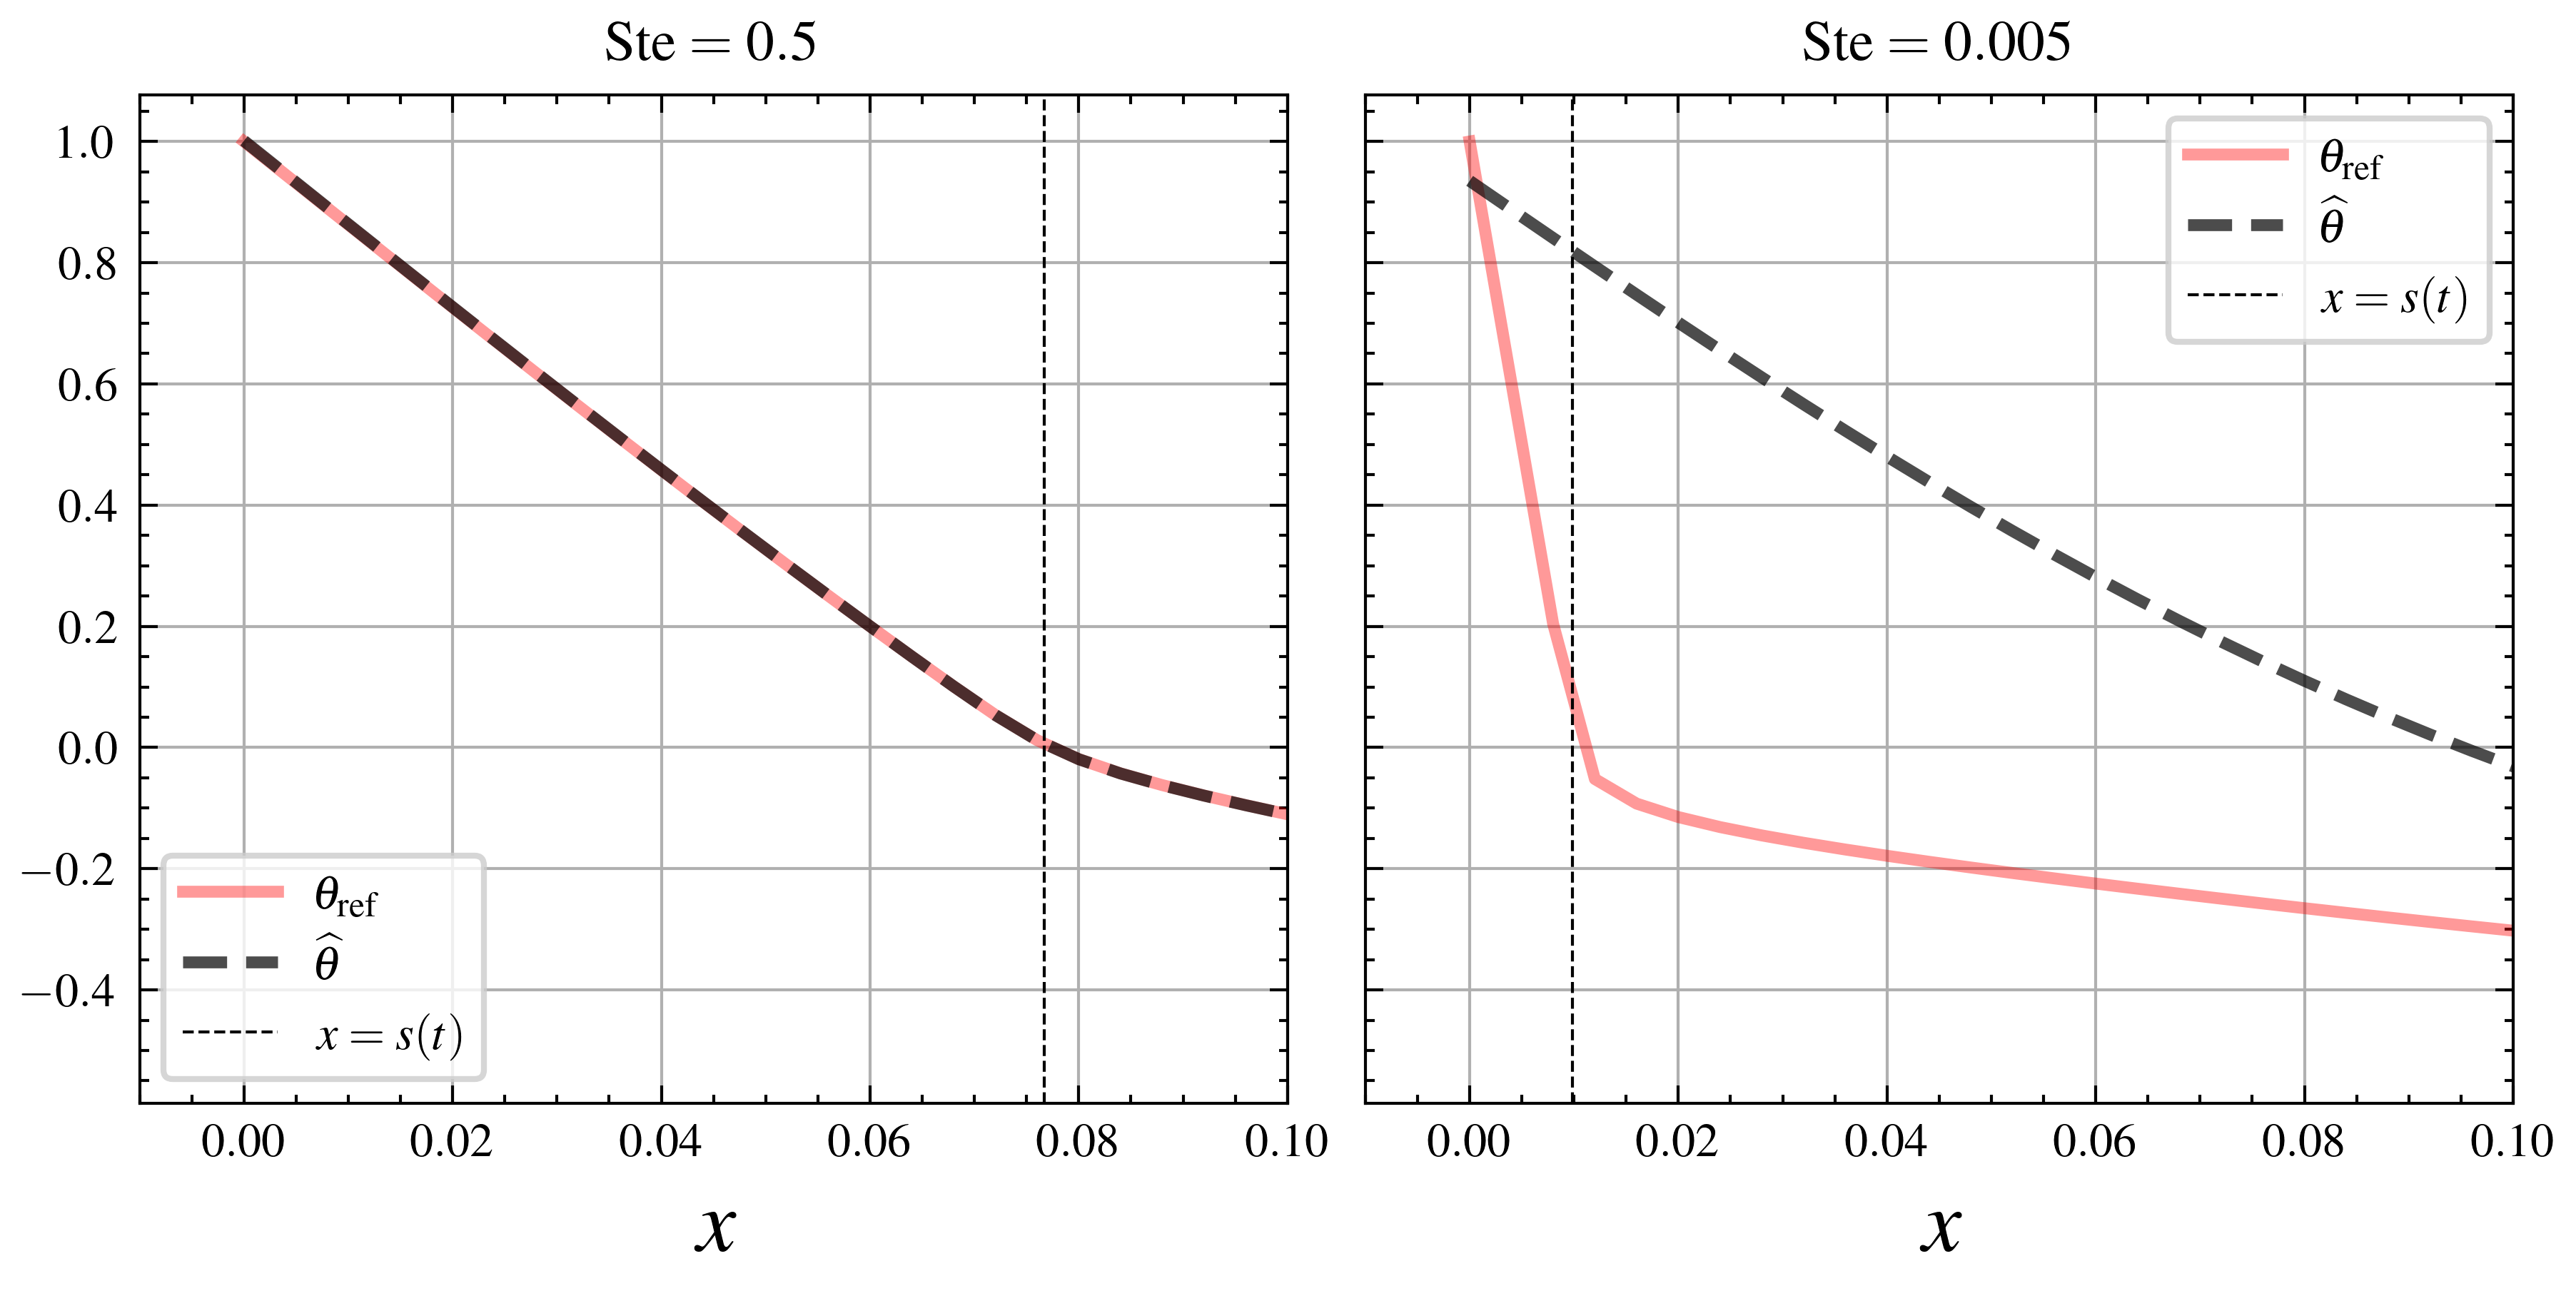

In [35]:
fig, axs = plt.subplots(1, 2, figsize=(6, 3), sharey=True, constrained_layout=True)

axs[0].grid(True)
axs[0].plot(x_ref[0], T_ref[-1], 'r-', lw = 2, alpha =.4,  label = r'$\theta_\mathrm{ref}$')
axs[0].plot(x_ref[0], T_pred_1[-1], 'k--',lw = 2, alpha= .7, label = r'$\widehat\theta$')
pos = s1(1.)
axs[0].axvline(pos, c='k', ls='--', lw=0.5, label='$x = s(t)$')
axs[0].set_xlim(-0.01, 0.1)
axs[0].set_title('$\mathrm{Ste}=0.5$')
axs[0].set_xlabel('$x$', fontsize = 15)
axs[0].legend(frameon=True,)

axs[1].grid(True)
axs[1].plot(x_ref[0], T_ref2[-1], 'r-', lw = 2, alpha =.4,  label = r'$\theta_\mathrm{ref}$')
axs[1].plot(x_ref[0], T_pred_2[-1], 'k--',lw = 2, alpha= .7, label = r'$\widehat\theta$')
pos = s2(1.)
axs[1].axvline(pos, c='k', ls='--', lw=0.5, label='$ x= s(t)$')
axs[1].set_xlim(-0.01, 0.1)
axs[1].set_title('$\mathrm{Ste}=0.005$')
axs[1].set_xlabel('$x$', fontsize = 15)
axs[1].legend(frameon=True,)

#axs[1].legend(bbox_to_anchor=(.9, -0.4), ncol=1, columnspacing = 6)
#axs[1].set_xlim(-0.001, 0.03)
if save:
    plt.savefig(savefile + '1D_result_bis.pdf', bbox_inches = 'tight')   
    plt.savefig(savefile + '1D_result_bis.png', bbox_inches = 'tight')   
plt.show()